In [1]:
import glob
import os
import pandas as pd

In [2]:
# PycharmProjects/Capstone-LLM-Project-/Small_Normal_Data/CL_processed_chunks
# PycharmProjects/Capstone-LLM-Project-/Small_Normal_Data/GPT_processed_chunks
# PycharmProjects/Capstone-LLM-Project-/Small_Normal_Data/On_demand_report_2026-04-18T18_18_50.439Z_0c91c480-3b53-11f1-9003-bd29458e987d.csv
# "C:\Users\tcsim\PycharmProjects\Capstone-LLM-Project-\Small_suspious_logs\CL_processed_chunks"
# "C:\Users\tcsim\PycharmProjects\Capstone-LLM-Project-\Small_suspious_logs\GPT_processed_chunks"

In [3]:
# puts all the chunks back together
def combiner(f):
    files = glob.glob(os.path.join(f,"*processed*"))
    df = pd.DataFrame()
    for i in files:
        df1 = pd.read_csv(i)
        df = pd.concat([df, df1], ignore_index=True)
    df["RowID"].duplicated().any()
    df = df.drop_duplicates(subset=["RowID"], keep="first")
    df = df.sort_values(by="RowID")
    return df

In [4]:
GPT_N =combiner(r"Small_Normal_Data/GPT_processed_chunks")
Claude_N =combiner(r"Small_Normal_Data/CL_processed_chunks")
Claude_S =combiner(r"Small_suspicious_logs\CL_processed_chunks")
GPT_S =combiner(r"Small_suspicious_logs\GPT_processed_chunks")

In [5]:
Claude_S

,TargetUserName,Timestamp,SubjectUserName,EventID,ParentProcessName,CommandLine,ProcessName,RowID,Suspicion_Score,summary
800,pizza,2026-04-20 18:00:18.158943+00:00,DESKTOP-A3EGFSV$,4688,C:\Windows\System32\svchost.exe,taskhostw.exe $(Arg0),NaN,0,2,Normal taskhostw.exe process from svchost
801,NaN,2026-04-20 18:00:18.704304+00:00,DESKTOP-A3EGFSV$,4689,NaN,NaN,C:\Windows\System32\ctfmon.exe,1,1,Normal ctfmon.exe process termination
802,-,2026-04-20 18:00:19.056101+00:00,pizza,4688,C:\Windows\System32\WindowsPowerShell\v1.0\pow...,"""C:\WINDOWS\system32\wevtutil.exe"" cl Security",NaN,2,11,Clearing Security event log via wevtutil
803,NaN,2026-04-20 18:00:19.082523+00:00,NaN,1102,NaN,NaN,NaN,3,10,Event log cleared EventID 1102
804,NaN,2026-04-20 18:00:19.083939+00:00,pizza,4689,NaN,NaN,C:\Windows\System32\wevtutil.exe,4,9,wevtutil.exe process termination after log clear
...,...,...,...,...,...,...,...,...,...,...
1145,NaN,2026-04-20 18:26:30.740854+00:00,SYSTEM,4672,NaN,NaN,NaN,1565,1,Normal privilege use event
1146,-,2026-04-20 18:26:30.742781+00:00,DESKTOP-A3EGFSV$,4688,C:\Windows\System32\services.exe,C:\WINDOWS\servicing\TrustedInstaller.exe,NaN,1566,2,Standard TrustedInstaller system process launch
1147,-,2026-04-20 18:26:30.789238+00:00,DESKTOP-A3EGFSV$,4688,C:\Windows\System32\svchost.exe,C:\WINDOWS\winsxs\amd64_microsoft-windows-serv...,NaN,1567,2,Standard TiWorker servicing process launch
1148,NaN,2026-04-20 18:26:35.364809+00:00,DESKTOP-A3EGFSV$,4689,NaN,NaN,C:\Windows\System32\Dism\DismHost.exe,1568,1,Normal DISM process termination


In [6]:
# puts the top 5 chunks back together
def combinertop(f):
    files = glob.glob(os.path.join(f,"*top*"))
    df = pd.DataFrame()
    for i in files:
        df1 = pd.read_csv(i)
        df = pd.concat([df, df1], ignore_index=True)
    df["RowID"].duplicated().any()
    df = df.drop_duplicates(subset=["RowID"], keep="first")
    df = df.sort_values(by="RowID")
    return df

In [7]:
GPT_NTOP =combinertop(r"Small_Normal_Data/GPT_processed_chunks")
Claude_NTOP =combinertop(r"Small_Normal_Data/CL_processed_chunks")
Claude_STOP =combinertop(r"Small_suspicious_logs\CL_processed_chunks")
GPT_STOP =combinertop(r"Small_suspicious_logs\GPT_processed_chunks")

In [8]:
# Normal 
# "C:\Users\tcsim\PycharmProjects\Capstone-LLM-Project-\Small_Normal_Data\C_small_normal.csv"

Normal = pd.read_csv(r"C:\Users\tcsim\PycharmProjects\Capstone-LLM-Project-\Small_Normal_Data\C_small_normal.csv")
# Sus
# "C:\Users\tcsim\PycharmProjects\Capstone-LLM-Project-\Small_suspious_logs\C_suspicious logs.csv"


susipious = pd.read_csv(r"C:\Users\tcsim\PycharmProjects\Capstone-LLM-Project-\Small_suspious_logs\C_suspicious logs.csv")

In [9]:
GPT_NTOP = pd.merge(GPT_NTOP, Normal, on="RowID", how="left")
Claude_NTOP= pd.merge(Claude_NTOP, Normal, on="RowID", how="left")
Claude_STOP = pd.merge(Claude_STOP, susipious, on="RowID", how="left")
GPT_STOP = pd.merge(GPT_STOP, susipious, on="RowID", how="left")

In [10]:
GPT_NTOP 

,RowID,Suspicion_Score,summary,ProcessName,EventID,Timestamp,SubjectUserName,TargetUserName,ParentProcessName,CommandLine
0,0,0,NaN,NaN,1101,2026-04-18 17:00:02.450777+00:00,NaN,NaN,NaN,NaN
1,1,0,NaN,NaN,4688,2026-04-18 16:59:57.561752+00:00,-,-,NaN,NaN
2,2,0,NaN,NaN,4696,2026-04-18 16:59:57.561880+00:00,-,-,NaN,NaN
3,3,0,NaN,NaN,4826,2026-04-18 16:59:57.561886+00:00,-,NaN,NaN,NaN
4,4,0,NaN,NaN,4688,2026-04-18 16:59:57.573570+00:00,-,-,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
157,3782,6,Complex Edge command line,NaN,4688,2026-04-18 18:13:34.221680+00:00,pizza,-,C:\Program Files (x86)\Microsoft\Edge\Applicat...,"""C:\Program Files (x86)\Microsoft\Edge\Applica..."
158,3789,6,Background task with server name,NaN,4688,2026-04-18 18:14:21.119909+00:00,DESKTOP-7CV8A7M$,pizza,C:\Windows\System32\svchost.exe,"""C:\WINDOWS\system32\backgroundTaskHost.exe"" -..."
159,3790,6,RuntimeBroker with embedding,NaN,4688,2026-04-18 18:14:21.736504+00:00,DESKTOP-7CV8A7M$,pizza,C:\Windows\System32\svchost.exe,C:\Windows\System32\RuntimeBroker.exe -Embedding
160,3791,6,Background task with server name,NaN,4688,2026-04-18 18:14:22.171881+00:00,DESKTOP-7CV8A7M$,pizza,C:\Windows\System32\svchost.exe,"""C:\WINDOWS\system32\BackgroundTaskHost.exe"" -..."


In [11]:
# "C:\Users\tcsim\PycharmProjects\Capstone-LLM-Project-\TOP5"

In [12]:



# GPT_NTOP.to_csv(r"C:\Users\tcsim\PycharmProjects\Capstone-LLM-Project-\TOP5\GPT_NTOP", index=False)
# Claude_NTOP.to_csv(r"C:\Users\tcsim\PycharmProjects\Capstone-LLM-Project-\TOP5\Claude_NTOP", index=False)
# Claude_STOP.to_csv(r"C:\Users\tcsim\PycharmProjects\Capstone-LLM-Project-\TOP5\Claude_STOP", index=False)
# GPT_STOP.to_csv(r"C:\Users\tcsim\PycharmProjects\Capstone-LLM-Project-\TOP5\GPT_STOP", index=False)

In [13]:
Normal

,ProcessName,EventID,Timestamp,SubjectUserName,TargetUserName,ParentProcessName,CommandLine,RowID
0,NaN,4688,2026-04-18 16:59:57.561752+00:00,-,-,NaN,NaN,1
1,NaN,4696,2026-04-18 16:59:57.561880+00:00,-,-,NaN,NaN,2
2,NaN,4826,2026-04-18 16:59:57.561886+00:00,-,NaN,NaN,NaN,3
3,NaN,4688,2026-04-18 16:59:57.573570+00:00,-,-,NaN,NaN,4
4,NaN,4688,2026-04-18 16:59:58.512703+00:00,-,-,C:\Windows\System32\smss.exe,NaN,5
...,...,...,...,...,...,...,...,...
3854,C:\Windows\System32\UsoClient.exe,4689,2026-04-18 17:02:37.780914+00:00,DESKTOP-7CV8A7M$,NaN,NaN,NaN,625
3855,NaN,4688,2026-04-18 17:02:38.559252+00:00,pizza,-,C:\Program Files (x86)\Microsoft\Edge\Applicat...,"""C:\Program Files (x86)\Microsoft\Edge\Applica...",626
3856,NaN,4688,2026-04-18 17:02:39.842787+00:00,DESKTOP-7CV8A7M$,pizza,C:\Windows\System32\svchost.exe,"""C:\WINDOWS\system32\BackgroundTaskHost.exe"" -...",627
3857,C:\Windows\System32\backgroundTaskHost.exe,4689,2026-04-18 17:02:40.000019+00:00,pizza,NaN,NaN,NaN,628


In [14]:
# overall top 5
# "C:\Users\tcsim\PycharmProjects\Capstone-LLM-Project-\TOP5\Processed_Top5\Claude_NTOP.csv"
# "C:\Users\tcsim\PycharmProjects\Capstone-LLM-Project-\TOP5\Processed_Top5\Claude_STOP.csv"
# "C:\Users\tcsim\PycharmProjects\Capstone-LLM-Project-\TOP5\Processed_Top5\GPT_NTOP.csv"
# "C:\Users\tcsim\PycharmProjects\Capstone-LLM-Project-\TOP5\Processed_Top5\GPT_STOP.csv"


#Normal Wazuh
# "C:\Users\tcsim\PycharmProjects\Capstone-LLM-Project-\Small_Normal_Data\On_demand_report_2026-04-18T18_18_50.439Z_0c91c480-3b53-11f1-9003-bd29458e987d.csv"

# suspicious
# "C:\Users\tcsim\PycharmProjects\Capstone-LLM-Project-\Small_suspious_logs\On_demand_report_2026-04-20T18_29_04.390Z_cf569a60-3ce6-11f1-b73e-3bd7c4227409.csv"


In [15]:
# GPT_NTOP = pd.read_csv(r"C:\Users\tcsim\PycharmProjects\Capstone-LLM-Project-\TOP5\GPT_NTOP", index=False)
# Claude_NTOP.to_csv(r"C:\Users\tcsim\PycharmProjects\Capstone-LLM-Project-\TOP5\Claude_NTOP", index=False)
# Claude_STOP.to_csv(r"C:\Users\tcsim\PycharmProjects\Capstone-LLM-Project-\TOP5\Claude_STOP", index=False)
# GPT_STOP.to_csv(r"C:\Users\tcsim\PycharmProjects\Capstone-LLM-Project-\TOP5\GPT_STOP", index=False)

In [16]:
GPT_N

,ProcessName,EventID,Timestamp,SubjectUserName,TargetUserName,ParentProcessName,CommandLine,RowID,Suspicion_Score,summary
1715,NaN,1101,2026-04-18 17:00:02.450777+00:00,NaN,NaN,NaN,NaN,0,NaN,NaN
800,NaN,4688,2026-04-18 16:59:57.561752+00:00,-,-,NaN,NaN,1,0.0,NaN
801,NaN,4696,2026-04-18 16:59:57.561880+00:00,-,-,NaN,NaN,2,0.0,NaN
802,NaN,4826,2026-04-18 16:59:57.561886+00:00,-,NaN,NaN,NaN,3,0.0,NaN
803,NaN,4688,2026-04-18 16:59:57.573570+00:00,-,-,NaN,NaN,4,0.0,NaN
...,...,...,...,...,...,...,...,...,...,...
3994,NaN,4798,2026-04-18 18:15:28.846325+00:00,DESKTOP-7CV8A7M$,DefaultAccount,NaN,NaN,3854,0.0,NaN
3995,NaN,4798,2026-04-18 18:15:28.847160+00:00,DESKTOP-7CV8A7M$,Guest,NaN,NaN,3855,0.0,NaN
3996,NaN,4798,2026-04-18 18:15:28.848133+00:00,DESKTOP-7CV8A7M$,pizza,NaN,NaN,3856,0.0,NaN
3997,NaN,4799,2026-04-18 18:15:35.569235+00:00,pizza,Administrators,NaN,NaN,3857,0.0,NaN


In [17]:
# charts
# GPT_N 
# Claude_N 
# Claude_S 
# GPT_S

In [18]:
def filna(pdd):
    pdd["Suspicion_Score"] = pdd["Suspicion_Score"].fillna(0)


In [19]:
filna(GPT_N)
filna(Claude_N)
filna(Claude_S )
filna(GPT_S)


In [20]:
df3 = pd.read_csv(r"C:\Users\tcsim\PycharmProjects\Capstone-LLM-Project-\Small_Normal_Data\On_demand_report_2026-04-18T18_18_50.439Z_0c91c480-3b53-11f1-9003-bd29458e987d.csv")

In [21]:
df3

,rule\.level,rule\.id,rule\.description
0,7,19007,CIS Microsoft Windows 11 Enterprise Benchmark ...
1,7,19007,CIS Microsoft Windows 11 Enterprise Benchmark ...
2,3,19008,CIS Microsoft Windows 11 Enterprise Benchmark ...
3,3,19008,CIS Microsoft Windows 11 Enterprise Benchmark ...
4,3,19008,CIS Microsoft Windows 11 Enterprise Benchmark ...
...,...,...,...
3713,3,80730,Auditd: SELinux permission check.
3714,3,80730,Auditd: SELinux permission check.
3715,3,80730,Auditd: SELinux permission check.
3716,3,80730,Auditd: SELinux permission check.


In [22]:
bins = [-1, 2, 5, 8, 11, 16]
labels = [
    "0-2 Normal",
    "3-5 Low",
    "6-8 Medium",
    "9-11 High",
    "12-15 Critical"]

In [23]:
df3["Score_Range"] = pd.cut(df3[r"rule\.level"], bins=bins, labels=labels)

In [24]:
C4 = df3["Score_Range"].value_counts().sort_index()

In [25]:
plot_df = pd.DataFrame({
    
    "Wazuh": C4,
    
})

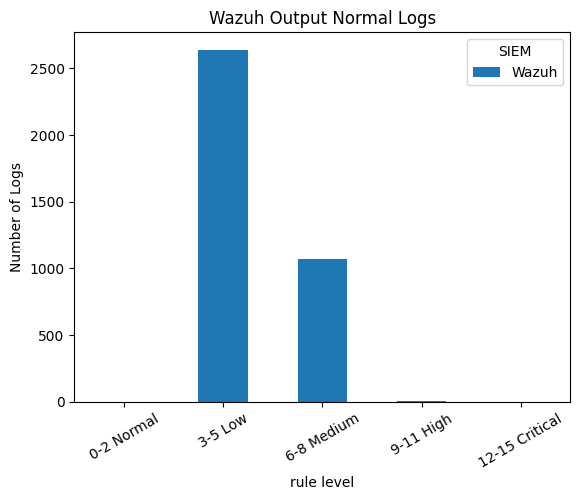

In [26]:
import matplotlib.pyplot as plt

plot_df.plot(kind="bar")

plt.title("Wazuh Output Normal Logs")
plt.xlabel("rule level")
plt.ylabel("Number of Logs")

plt.xticks(rotation=30)
plt.legend(title="SIEM")

plt.show()

In [27]:
bins = [-1, 2, 5, 8, 11, 16]
labels = [
    "0-2 Normal",
    "3-5 Low",
    "6-8 Medium",
    "9-11 High",
    "12-15 Critical"
]

In [28]:
GPT_N["Score_Range"] = pd.cut(GPT_N["Suspicion_Score"], bins=bins, labels=labels)
Claude_N["Score_Range"] = pd.cut(Claude_N["Suspicion_Score"], bins=bins, labels=labels)


In [29]:
C1 = GPT_N["Score_Range"].value_counts().sort_index()
C2 = Claude_N["Score_Range"].value_counts().sort_index()


In [30]:
C2

Score_Range
0-2 Normal        3026
3-5 Low            427
6-8 Medium         245
9-11 High          102
12-15 Critical      59
Name: count, dtype: int64

In [31]:
plot_df = pd.DataFrame({
    "gpt-4-turbo": C1,
    "claude-haiku-4-5": C2,
    
})

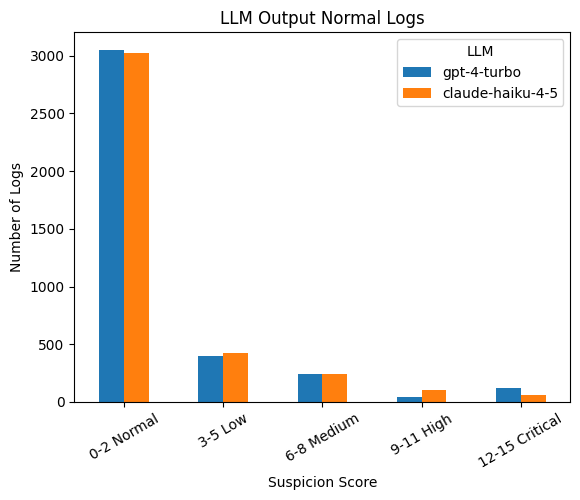

In [32]:
import matplotlib.pyplot as plt

plot_df.plot(kind="bar")

plt.title("LLM Output Normal Logs")
plt.xlabel("Suspicion Score")
plt.ylabel("Number of Logs")

plt.xticks(rotation=30)
plt.legend(title="LLM")

plt.show()

In [33]:
!pip install matplotlib

In [34]:
df4 = pd.read_csv(r"C:\Users\tcsim\PycharmProjects\Capstone-LLM-Project-\Small_suspious_logs\On_demand_report_2026-04-20T18_29_04.390Z_cf569a60-3ce6-11f1-b73e-3bd7c4227409.csv")

In [35]:
bins = [-1, 2, 5, 8, 11, 15]
labels = [
    "0-2 Normal",
    "3-5 Low",
    "6-8 Medium",
    "9-11 High",
    "12-15 Critical"
]

In [36]:
# len(GPT_S)
# len(Claude_S)

In [37]:
GPT_S["Score_Range"] = pd.cut(GPT_S["Suspicion_Score"], bins=bins, labels=labels)
Claude_S["Score_Range"] = pd.cut(Claude_S["Suspicion_Score"], bins=bins, labels=labels)


In [38]:
C3 = GPT_S["Score_Range"].value_counts().sort_index()
C4 = Claude_S["Score_Range"].value_counts().sort_index()


In [39]:
plot_df = pd.DataFrame({
    "gpt-4-turbo": C3,
    "claude-haiku-4-5": C4,
    
})

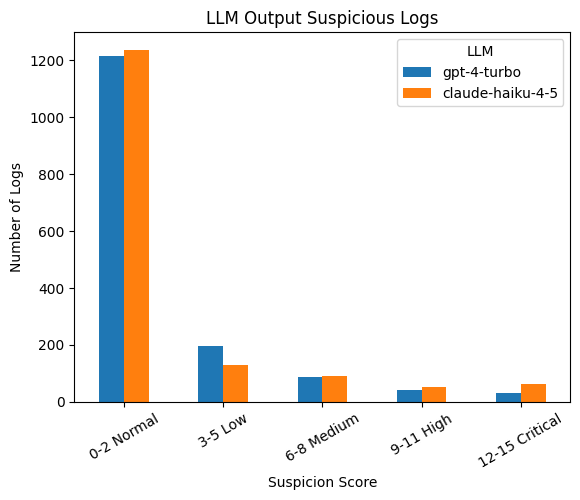

In [40]:
import matplotlib.pyplot as plt

plot_df.plot(kind="bar")

plt.title("LLM Output Suspicious Logs")
plt.xlabel("Suspicion Score")
plt.ylabel("Number of Logs")

plt.xticks(rotation=30)
plt.legend(title="LLM")

plt.show()

In [41]:
bins = [-1, 2, 5, 8, 11, 16]
labels = [
    "0-2 Normal",
    "3-5 Low",
    "6-8 Medium",
    "9-11 High",
    "12-15 Critical"]

In [42]:
df4["Score_Range"] = pd.cut(df4[r"rule\.level"], bins=bins, labels=labels)

In [43]:
C5 = df4["Score_Range"].value_counts().sort_index()

In [44]:
plot_df = pd.DataFrame({
    "Wazuh":C5,
  
    
})

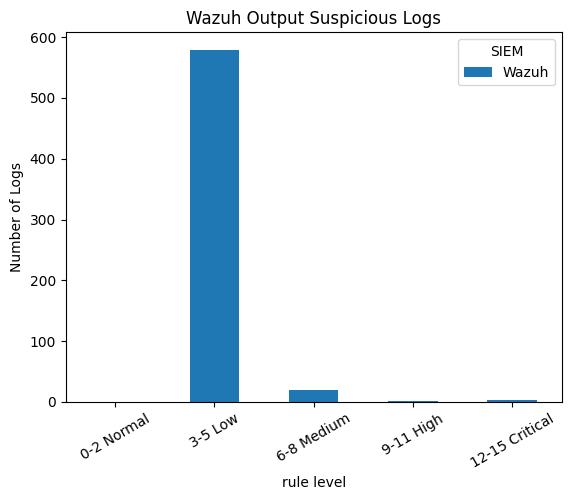

In [45]:
import matplotlib.pyplot as plt

plot_df.plot(kind="bar")

plt.title("Wazuh Output Suspicious Logs")
plt.xlabel("rule level")
plt.ylabel("Number of Logs")

plt.xticks(rotation=30)
plt.legend(title="SIEM")

plt.show()

In [46]:


print("Claude Normal ")
print(Claude_S["Score_Range"].value_counts())

print("GPT Normal")
print(GPT_S["Score_Range"].value_counts())

Claude Normal 
Score_Range
0-2 Normal        1236
3-5 Low            128
6-8 Medium          90
12-15 Critical      63
9-11 High           53
Name: count, dtype: int64
GPT Normal
Score_Range
0-2 Normal        1214
3-5 Low            196
6-8 Medium          88
9-11 High           41
12-15 Critical      31
Name: count, dtype: int64


In [47]:

print("Claude Normal ")
print(Claude_N["Score_Range"].value_counts())

print("GPT Normal")
print(GPT_N["Score_Range"].value_counts())

Claude Normal 
Score_Range
0-2 Normal        3026
3-5 Low            427
6-8 Medium         245
9-11 High          102
12-15 Critical      59
Name: count, dtype: int64
GPT Normal
Score_Range
0-2 Normal        3050
3-5 Low            402
6-8 Medium         246
12-15 Critical     117
9-11 High           44
Name: count, dtype: int64


In [48]:
GPT_S

,TargetUserName,Timestamp,SubjectUserName,EventID,ParentProcessName,CommandLine,ProcessName,RowID,Suspicion_Score,summary,Score_Range
800,pizza,2026-04-20 18:00:18.158943+00:00,DESKTOP-A3EGFSV$,4688,C:\Windows\System32\svchost.exe,taskhostw.exe $(Arg0),NaN,0,3,Unusual process launch,3-5 Low
801,NaN,2026-04-20 18:00:18.704304+00:00,DESKTOP-A3EGFSV$,4689,NaN,NaN,C:\Windows\System32\ctfmon.exe,1,2,Normal process termination,0-2 Normal
802,-,2026-04-20 18:00:19.056101+00:00,pizza,4688,C:\Windows\System32\WindowsPowerShell\v1.0\pow...,"""C:\WINDOWS\system32\wevtutil.exe"" cl Security",NaN,2,10,Security log cleared,9-11 High
803,NaN,2026-04-20 18:00:19.082523+00:00,NaN,1102,NaN,NaN,NaN,3,9,Audit log cleared,9-11 High
804,NaN,2026-04-20 18:00:19.083939+00:00,pizza,4689,NaN,NaN,C:\Windows\System32\wevtutil.exe,4,2,Normal process termination,0-2 Normal
...,...,...,...,...,...,...,...,...,...,...,...
1145,NaN,2026-04-20 18:26:30.740854+00:00,SYSTEM,4672,NaN,NaN,NaN,1565,2,SYSTEM account special privileges,0-2 Normal
1146,-,2026-04-20 18:26:30.742781+00:00,DESKTOP-A3EGFSV$,4688,C:\Windows\System32\services.exe,C:\WINDOWS\servicing\TrustedInstaller.exe,NaN,1566,3,Unusual command line parameters,3-5 Low
1147,-,2026-04-20 18:26:30.789238+00:00,DESKTOP-A3EGFSV$,4688,C:\Windows\System32\svchost.exe,C:\WINDOWS\winsxs\amd64_microsoft-windows-serv...,NaN,1567,3,Unusual command line parameters,3-5 Low
1148,NaN,2026-04-20 18:26:35.364809+00:00,DESKTOP-A3EGFSV$,4689,NaN,NaN,C:\Windows\System32\Dism\DismHost.exe,1568,2,Normal process termination,0-2 Normal


In [49]:
Claude_N

,ProcessName,EventID,Timestamp,SubjectUserName,TargetUserName,ParentProcessName,CommandLine,RowID,Suspicion_Score,summary,Score_Range
1715,NaN,1101,2026-04-18 17:00:02.450777+00:00,NaN,NaN,NaN,NaN,0,0,Normal audit log cleared event,0-2 Normal
800,NaN,4688,2026-04-18 16:59:57.561752+00:00,-,-,NaN,NaN,1,1,Process creation event with missing critical data,0-2 Normal
801,NaN,4696,2026-04-18 16:59:57.561880+00:00,-,-,NaN,NaN,2,1,Credential manager event with missing process ...,0-2 Normal
802,NaN,4826,2026-04-18 16:59:57.561886+00:00,-,NaN,NaN,NaN,3,1,Clipboard event with missing process information,0-2 Normal
803,NaN,4688,2026-04-18 16:59:57.573570+00:00,-,-,NaN,NaN,4,1,Process creation event with missing critical data,0-2 Normal
...,...,...,...,...,...,...,...,...,...,...,...
3994,NaN,4798,2026-04-18 18:15:28.846325+00:00,DESKTOP-7CV8A7M$,DefaultAccount,NaN,NaN,3854,2,DefaultAccount enumeration event,0-2 Normal
3995,NaN,4798,2026-04-18 18:15:28.847160+00:00,DESKTOP-7CV8A7M$,Guest,NaN,NaN,3855,2,Guest account enumeration event,0-2 Normal
3996,NaN,4798,2026-04-18 18:15:28.848133+00:00,DESKTOP-7CV8A7M$,pizza,NaN,NaN,3856,2,Pizza user account enumeration event,0-2 Normal
3997,NaN,4799,2026-04-18 18:15:35.569235+00:00,pizza,Administrators,NaN,NaN,3857,3,User added to Administrators group,3-5 Low
